# Workshop: Visualizing a hybrid model

## Two options for the models:
- GA, 2 basins
- UT, 4 basins

## GA:
The models were trained for 4 epochs on 2 basins in Georgia

The basins used were:

| HUC      | Basin Name                   |
| -------- | ---------------------------- |
| 02177000 | Chattooga River near Clayton |
| 02349900 | Turkey Creek at Byronville   |

### UT:
The models were trained for 30 epochs on 4 basins in Utah

The basins used were:

| HUC      | Basin Name                           |
| -------- | ------------------------------------ |
| 09312600 | White River near Soldier Summit      |
| 09378170 | South Creek near Monticello          |
| 09404450 | East Fork Virgin River near Glendale |
| 10234500 | Beaver River near Beaver             |


## Imports

In [43]:
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

from neuralhydrology.evaluation.metrics import nse

## Loading the workshop data

A helper function to load in the data from memory.

In [42]:
def load_workshop_data(dir: str, us_state: str = "GA",) -> dict:
    # Testing data for three LSTM-dCFE models, each trained on 2 basins.
    # 1. Dynamic stateeters (the default)
    # 2. Operational Averaged Parameters
    # 3. Oracle Averaged Parameters
    
    # Test results in two pickle files for each model:
    # 1. test_all_output.p - contains the predicted catchment internal storage states and parameters of the hybrid model.
    # 2. test_results.p - contains the streamflow predictions and observations.
    prefix = "GA_2basins_snowdcfe"
    epoch = "004"
    if us_state == "UT":
        prefix = "UT_4basins_snowdcfe"
        epoch = "030"
        
    # Load the data for each model.
    
    # Load Dynamic Parameters
    with open(Path(dir) / f"{prefix}_dynamic" / f"model_epoch{epoch}" / "test_all_output.p", "rb") as f:
        dynamic_states_and_params = pickle.load(f)
    with open(Path(dir) / f"{prefix}_dynamic" / f"model_epoch{epoch}" / "test_results.p", "rb") as f:
        dynamic_streamflow = pickle.load(f)
    
    # Load Operational Averaged Parameters
    with open(Path(dir) / f"{prefix}_operational_average" / f"model_epoch{epoch}" / "test_all_output.p", "rb") as f:
        operational_states_and_params = pickle.load(f)
    with open(Path(dir) / f"{prefix}_operational_average" / f"model_epoch{epoch}" / "test_results.p", "rb") as f:
        operational_streamflow = pickle.load(f)

    # Load Oracle Averaged Parameters
    with open(Path(dir) / f"{prefix}_oracle_average" / f"model_epoch{epoch}" / "test_all_output.p", "rb") as f:
        oracle_states_and_params = pickle.load(f)
    with open(Path(dir) / f"{prefix}_oracle_average" / f"model_epoch{epoch}" / "test_results.p", "rb") as f:
        oracle_streamflow = pickle.load(f)  
    
    return {
        "dynamic":      {
                        "streamflow": dynamic_streamflow,
                        "states_and_params": dynamic_states_and_params
                        },
        "operational":  {
                        "streamflow": operational_streamflow,
                        "states_and_params": operational_states_and_params
                        },
        "oracle":       {
                        "streamflow": oracle_streamflow,
                        "states_and_params": oracle_states_and_params
                        }
            }

If the below cell doesn't run for you, modify `workshop_data_dir` to be the absolute path.

In [46]:
# Jupyter notebook can handle relative pathing.
workshop_data_dir = "./workshop_data/"
# us_state can be either of "GA" or "UT". Default: "GA"
workshop_data = load_workshop_data(dir = workshop_data_dir, us_state="GA")

## Plotting Streamflow Predictions for all models

First, a function to help plot the streamflow for basins in our set.

In [47]:
# Function for plotting the observed and predicted streamflow given a basin.
def plot_basin_streamflow(basin: str) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1)
    
    # Test period dates are the same for each model, use dynamic by default
    dates = workshop_data["dynamic"]["streamflow"][basin]["1D"]["xr"]["datetime"] 
    
    # Observation data is the same for each model, use dynamic by default
    observed_streamflow = workshop_data["dynamic"]["streamflow"][basin]["1D"]["xr"]["QObs(mm/d)_obs"] 
    
    # Load streamflow predictions
    dynamic_streamflow = workshop_data["dynamic"]["streamflow"][basin]["1D"]["xr"]["QObs(mm/d)_sim"]
    operational_streamflow = workshop_data["oracle"]["streamflow"][basin]["1D"]["xr"]["QObs(mm/d)_sim"]
    oracle_streamflow = workshop_data["operational"]["streamflow"][basin]["1D"]["xr"]["QObs(mm/d)_sim"]
    
    '''
    Compute Nash-Sutcliffe Efficiency Metric for each model.
    
    Our hybrid implementation failed to integrate the automatic metric computation that
    is available through NeuralHydrology so we have to manually compute metrics for now.
    Fix coming soon.
    '''
    dynamic_nse = nse(observed_streamflow, dynamic_streamflow)
    operational_nse = nse(observed_streamflow, operational_streamflow)
    oracle_nse = nse(observed_streamflow, oracle_streamflow)
    
    # Plot the observations and predictions
    ax.plot(dates,
            observed_streamflow,
            label="Observed",
            color='black')
    ax.plot(dates,
            dynamic_streamflow,
            label=f"Dynamic dCFE, NSE: {dynamic_nse:.4f}",
            color='red')
    ax.plot(dates,
            operational_streamflow,
            label=f"Operational Averaged dCFE, NSE: {operational_nse:.4f}",
            color='blue')
    ax.plot(dates,
             oracle_streamflow,
             label=f"Oracle Averaged dCFE, NSE: {oracle_nse:.4f}",
             color='green')
    ax.set_ylabel("Q [mm/d]")
    ax.set_xlabel("Date [yr]")
    ax.set_title(f"Streamflow Predictions for Basin ID: {basin}")
    ax.legend()
    ax.grid()
    return fig, ax
    

### Basin Streamflow

Observed streamflow versus predicted streamflow for each of the three modes.

* NSE for each model can be found in the legend.

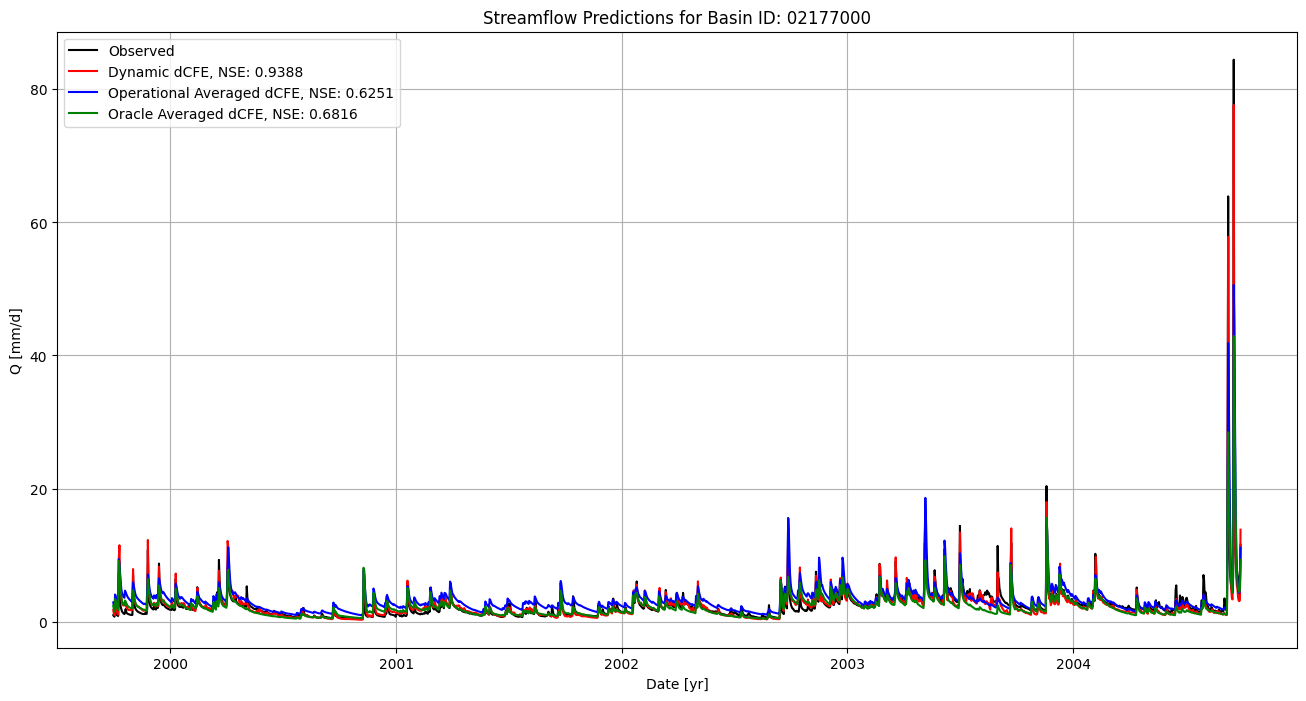

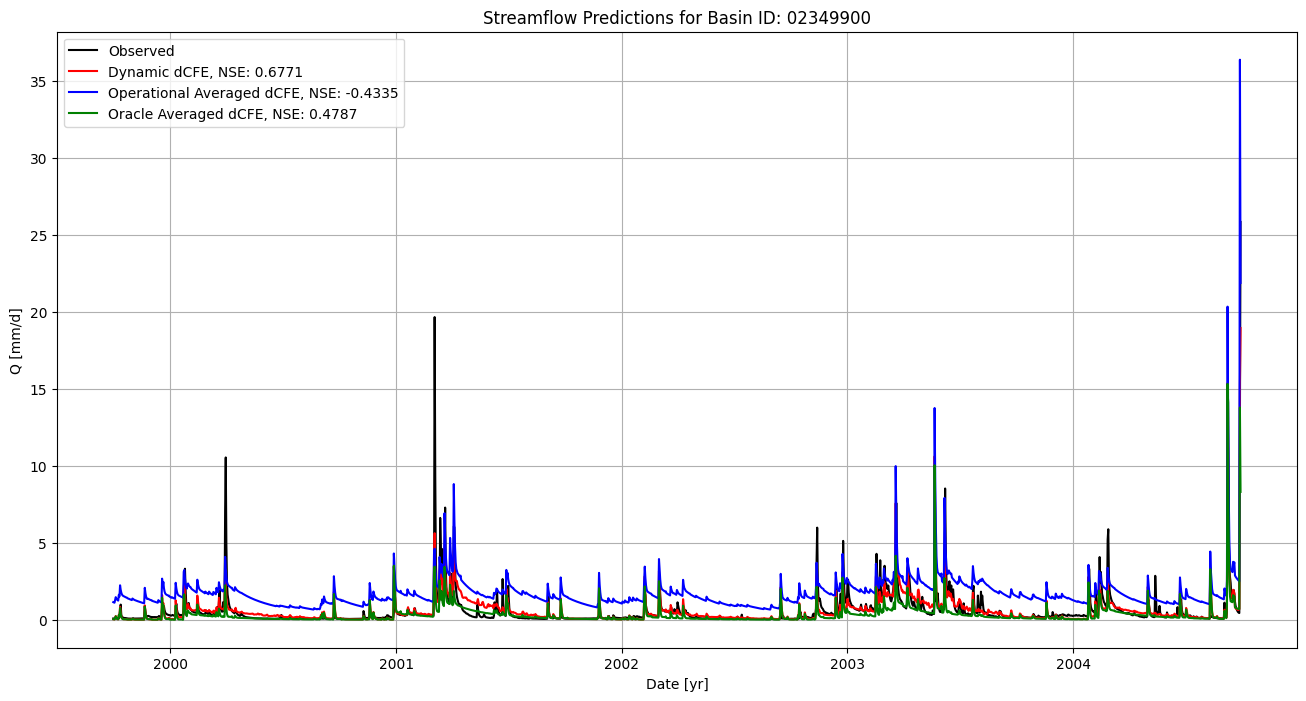

In [48]:
basins= list(workshop_data["dynamic"]["streamflow"].keys())
for i, basin in enumerate(basins):
    fig, ax = plot_basin_streamflow(basins[i])

## Plotting the internal storage states and parameters

First, some functions to make plotting easier.

In [49]:
def plot_basin_storage_states(basin: str) -> tuple[plt.Figure, plt.Axes]:
    # Plots the LSTM-predicted dCFE basin storage states.
    # Spinup period: 365 days long, gets states to more physically meaningful magnitudes before prediction period
    state_keys = list(workshop_data["dynamic"]["states_and_params"][basin]["spinup_internal_states"])
    state_dates = workshop_data["dynamic"]["states_and_params"]["datetime"]
    
    fig, ax = plt.subplots(figsize=(16,2.5*len(state_keys)), nrows=len(state_keys), ncols=1)
    
    dynamic_spinup_internal_states = workshop_data["dynamic"]["states_and_params"][basin]["spinup_internal_states"]
    dynamic_prediction_internal_states = workshop_data["dynamic"]["states_and_params"][basin]["prediction_internal_states"]
    
    operational_spinup_internal_states = workshop_data["operational"]["states_and_params"][basin]["spinup_internal_states"]
    operational_prediction_internal_states = workshop_data["operational"]["states_and_params"][basin]["prediction_internal_states"]
    
    oracle_spinup_internal_states = workshop_data["oracle"]["states_and_params"][basin]["spinup_internal_states"]
    oracle_prediction_internal_states = workshop_data["oracle"]["states_and_params"][basin]["prediction_internal_states"]
    
    # Loop through each of the dCFE parameters and plot.
    for i, state_i in enumerate(state_keys):
        show_label = (i == 0)
        
        # Dynamic Mode - Spinup period internal_states
        ax[i].plot(state_dates, dynamic_spinup_internal_states[state_i],
                color="red", linestyle='--', alpha=0.5,
                label="Dynamic Spinup" if show_label else None)
        # Dynamic Mode - Prediction period internal_states
        ax[i].plot(state_dates, dynamic_prediction_internal_states[state_i],
                color="red", linestyle='-',
                label="Dynamic Prediction" if show_label else None)
        # Operational Mode - Spinup period internal_states
        ax[i].plot(state_dates, operational_spinup_internal_states[state_i],
                color="blue", linestyle='--', alpha=0.5,
                label="Operational Spinup" if show_label else None)
        # Operational Mode - Prediction period internal_states
        ax[i].plot(state_dates, operational_prediction_internal_states[state_i],
                color="blue", linestyle='-',
                label="Operational Prediction" if show_label else None)
        # Oracle Mode - Spinup period internal_states
        ax[i].plot(state_dates, oracle_spinup_internal_states[state_i],
                color="green", linestyle='--', alpha=0.5,
                label="Oracle Spinup" if show_label else None)
        # Oracle Mode - Prediction period internal_states
        ax[i].plot(state_dates, oracle_prediction_internal_states[state_i],
                color="green", linestyle='-',
                label="Oracle Prediction" if show_label else None)
        
        ax[i].set_ylabel(f"{state_i}")

    # Pull handles/labels from the first axes only.
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3)
    
    fig.suptitle(f"Internal States for Basin ID: {basin}")
    plt.tight_layout(rect=[0, 0.05, 1, 0.99])
    
    return fig, ax

def plot_basin_parameters(basin: str)-> tuple[plt.Figure, plt.Axes]:
    # Plots the LSTM-predicted dCFE input parameters.
    # Spinup period: 365 days long, gets input parameters to more physically meaningful magnitudes before prediction period
    
    param_keys = list(workshop_data["dynamic"]["states_and_params"][basin]["spinup_parameters"])
    param_dates = workshop_data["dynamic"]["states_and_params"]["datetime"]
    
    fig, ax = plt.subplots(figsize=(16,2.5*len(param_keys)), nrows=len(param_keys), ncols=1)
    
    dynamic_spinup_params = workshop_data["dynamic"]["states_and_params"][basin]["spinup_parameters"]
    dynamic_prediction_params = workshop_data["dynamic"]["states_and_params"][basin]["prediction_parameters"]
    
    operational_spinup_params = workshop_data["operational"]["states_and_params"][basin]["spinup_parameters"]
    operational_prediction_params = workshop_data["operational"]["states_and_params"][basin]["prediction_parameters"]
    
    oracle_spinup_params = workshop_data["oracle"]["states_and_params"][basin]["spinup_parameters"]
    oracle_prediction_params = workshop_data["oracle"]["states_and_params"][basin]["prediction_parameters"]
    
    # Loop through each of the dCFE parameters and plot.
    for i, param_i in enumerate(param_keys):
        show_label = (i == 0)
        
        # Dynamic Mode - Spinup period parameters
        ax[i].plot(param_dates, dynamic_spinup_params[param_i],
                color="red", linestyle='--', alpha=0.5,
                label="Dynamic Spinup" if show_label else None)
        # Dynamic Mode - Prediction period parameters
        ax[i].plot(param_dates, dynamic_prediction_params[param_i],
                color="red", linestyle='-',
                label="Dynamic Prediction" if show_label else None)
        # Operational Mode - Spinup period parameters
        ax[i].plot(param_dates, operational_spinup_params[param_i],
                color="blue", linestyle='--', alpha=0.5,
                label="Operational Spinup" if show_label else None)
        # Operational Mode - Prediction period parameters
        ax[i].plot(param_dates, operational_prediction_params[param_i],
                color="blue", linestyle='-',
                label="Operational Prediction" if show_label else None)
        # Oracle Mode - Spinup period parameters
        ax[i].plot(param_dates, oracle_spinup_params[param_i],
                color="green", linestyle='--', alpha=0.5,
                label="Oracle Spinup" if show_label else None)
        # Oracle Mode - Prediction period parameters
        ax[i].plot(param_dates, oracle_prediction_params[param_i],
                color="green", linestyle='-',
                label="Oracle Prediction" if show_label else None)
        
        ax[i].set_ylabel(f"{param_i}")

    # Pull handles/labels from the first axes only.
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3)
    
    fig.suptitle(f"Parameters for Basin ID: {basin}")
    plt.tight_layout(rect=[0, 0.02, 1, 0.99])
    
    return fig, ax

### Basin Parameters

The parameters are the LSTM-predicted inputs to the dCFE process-based model.

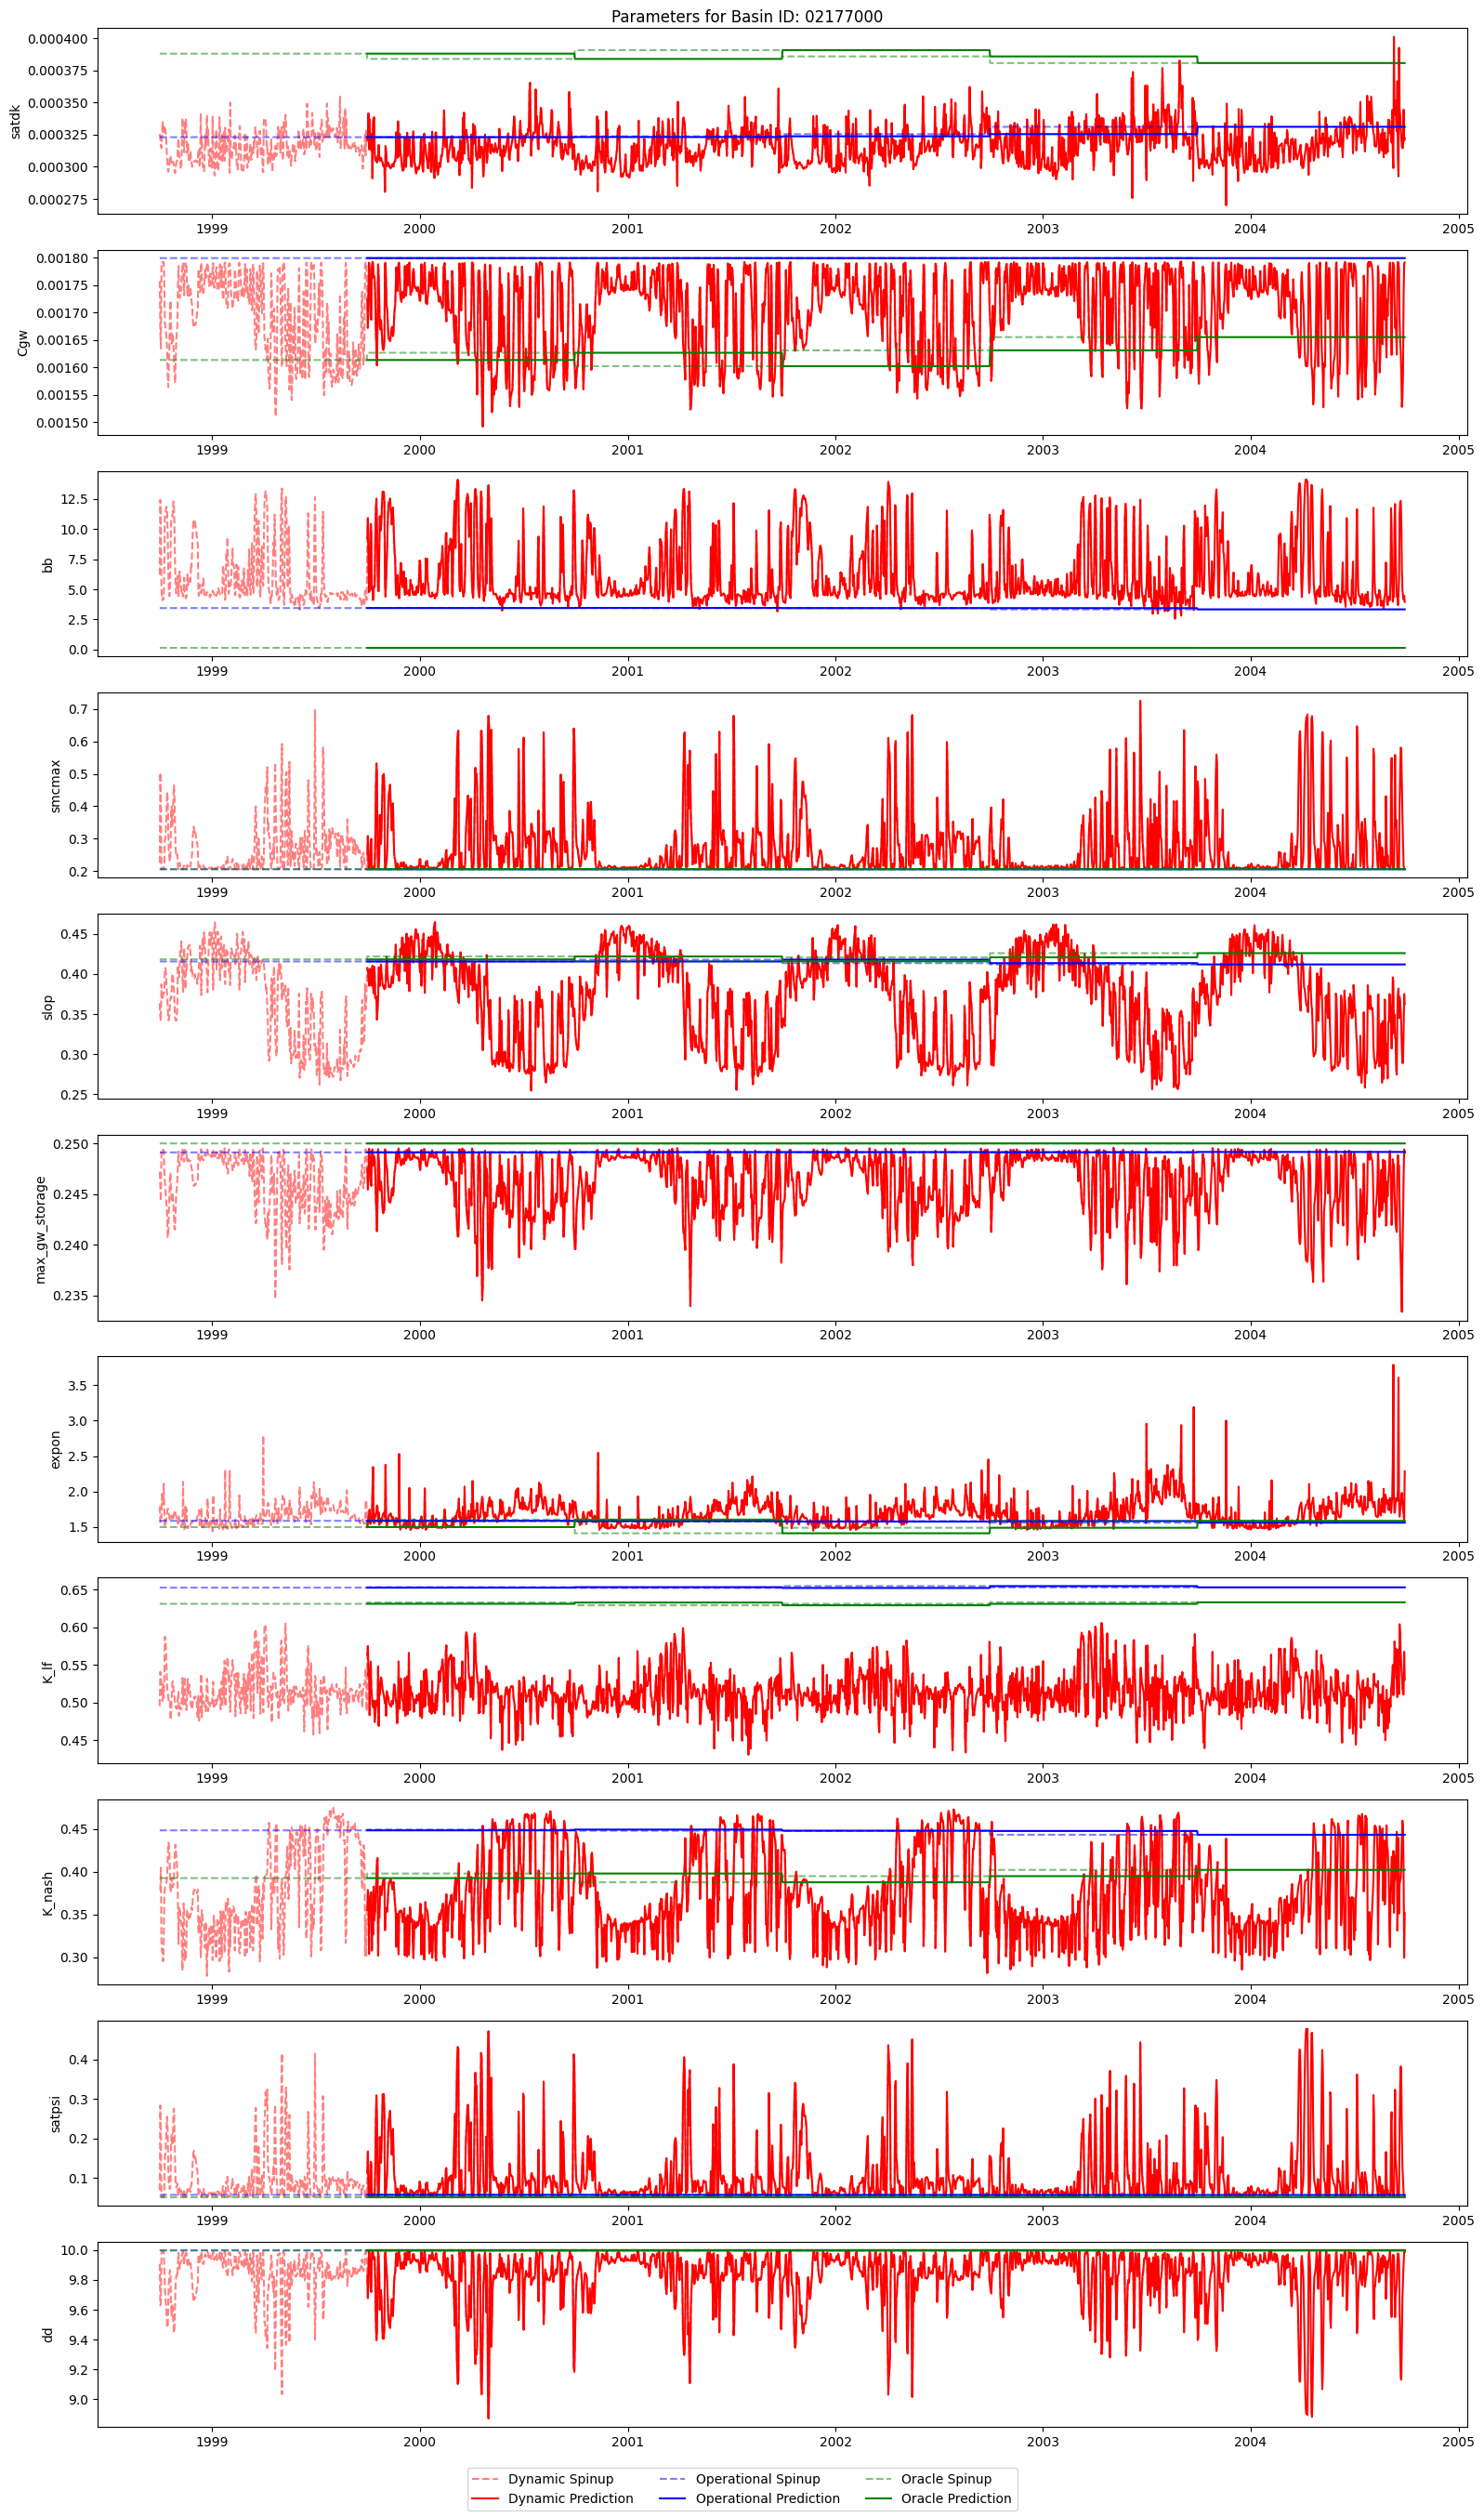

In [50]:
# Select between any of the basins from the chosen model.
fig, ax = plot_basin_parameters(basins[0])

# Basin Internal Storage States

Storage states are used to produce the final streamflow prediction.

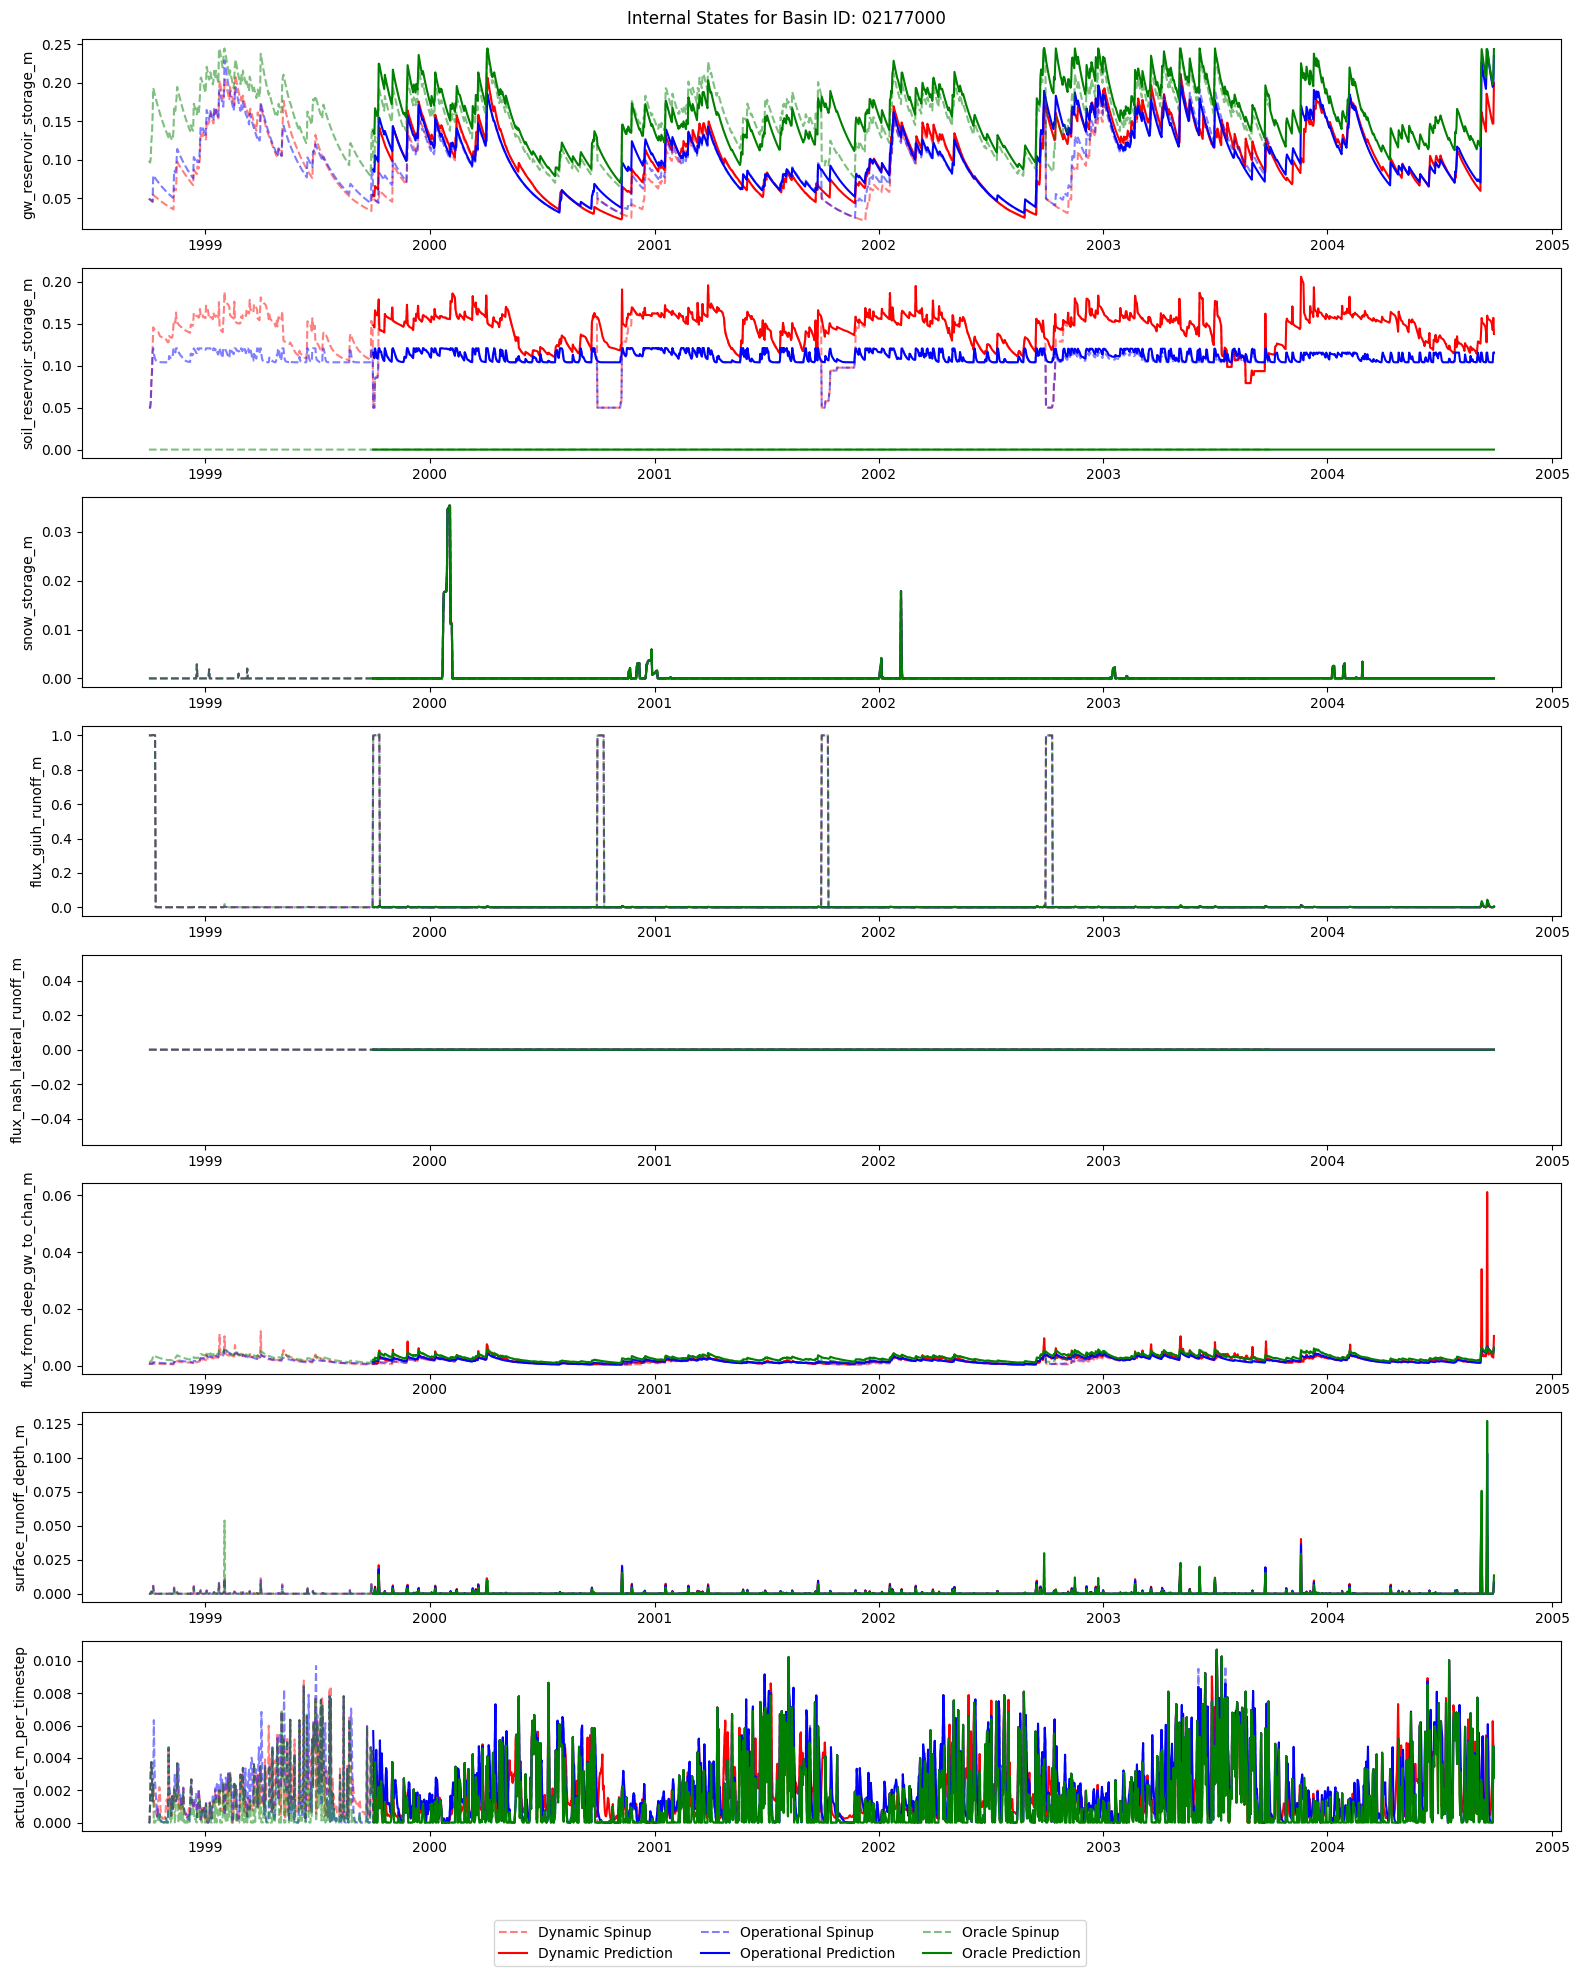

In [51]:
# Select between any of the basins from the chosen model.
fig, ax = plot_basin_storage_states(basins[0])